In [1]:
# WorkFlow

# Dataset
#    ↓
# Explore data
#    ↓
# Create PyTorch Dataset
#    ↓
# Preprocess images
#    ↓
# Load ResNet18
#    ↓
# Train model
#    ↓
# Validate model
#    ↓
# Test model
#    ↓
# Evaluate metrics
#    ↓
# Analyze safety/ODD gaps

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import random
import warnings
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

# ! pip install torch
# ! pip install cuda
# ! pip install pillow

In [3]:
warnings.filterwarnings('ignore')


Data exploration 

In [10]:
train_labels = pd.read_csv("E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//assigment3//train//labels.csv")
test_labels = pd.read_csv("E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//assigment3//test//labels.csv")

In [11]:
train_labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [13]:
train_labels.describe()

,frame,px_traffic_light,px_pedestrian,px_vehicle
count,7200.000000,7200.000000,7200.000000,7200.000000
mean,35995.000000,218.503611,70.369306,2259.733889
std,20786.053016,310.809585,217.723742,4085.054794
min,0.000000,0.000000,0.000000,0.000000
25%,17997.500000,33.000000,0.000000,44.000000
50%,35995.000000,136.000000,2.000000,363.000000
75%,53992.500000,343.000000,34.000000,1892.250000
max,71990.000000,4199.000000,4219.000000,27791.000000


In [14]:
print(train_labels['has_traffic_light'].value_counts(),"\n",train_labels['has_pedestrian'].value_counts(),"\n",train_labels['has_vehicle'].value_counts())

has_traffic_light
True     5276
False    1924
Name: count, dtype: int64 
 has_pedestrian
False    5482
True     1718
Name: count, dtype: int64 
 has_vehicle
True     5458
False    1742
Name: count, dtype: int64


In [18]:
print("Number of training Imgaes : ",len(train_labels),'\n')
print("Number of testing Images : ",len(test_labels))

Number of training Imgaes :  7200 

Number of testing Images :  3600


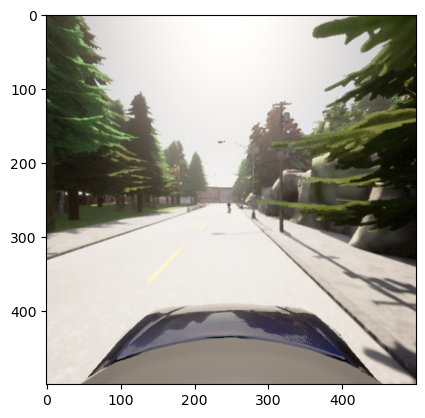

In [15]:
img = Image.open("E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//assigment3//train//rgb-front//000000.jpg")
plt.imshow(img)
plt.show()
# plt.axis('off')

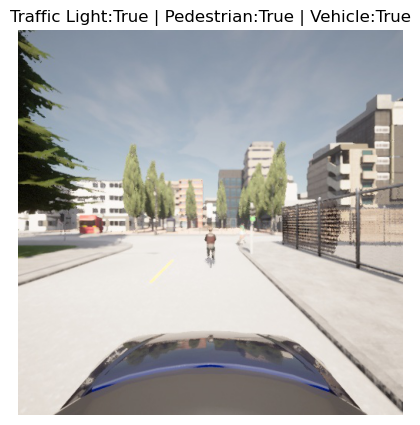

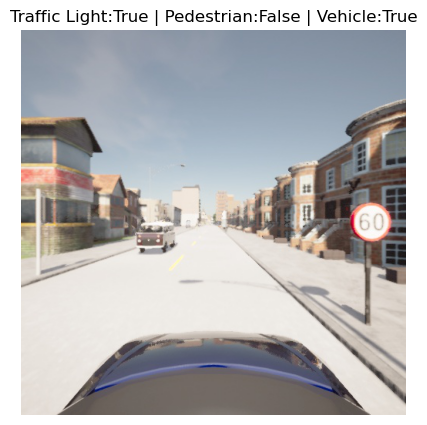

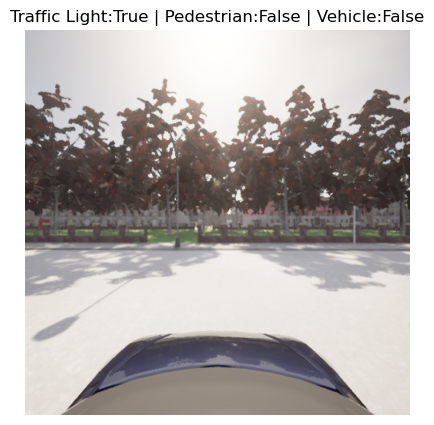

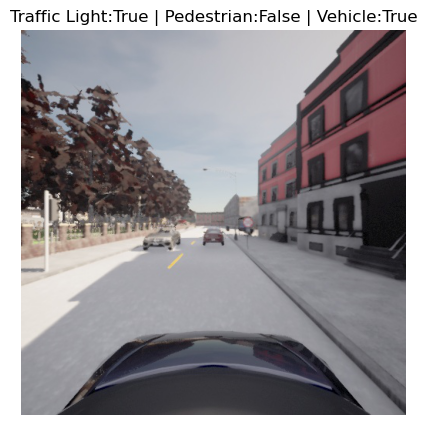

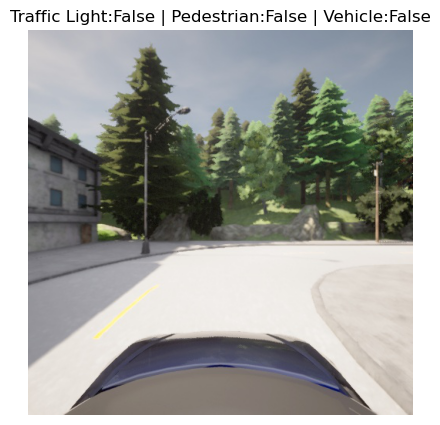

In [48]:
# Randomly selecting 5 Images from the training set and visualizing them
train_labels_images_path = "E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//assigment3//train//rgb-front//"
random_samples = train_labels.sample(5)
# random_samples
for idx, row in random_samples.iterrows():
    frame = str(row['frame']).zfill(6)
    
    # Image path
    img_path = f'{train_labels_images_path}//{frame}.jpg'

    #Opening image
    img = Image.open(img_path)
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(
        f"Traffic Light:{row['has_traffic_light']} | "
        f"Pedestrian:{row['has_pedestrian']} | "
        f"Vehicle:{row['has_vehicle']}"
    )
    plt.axis('off')

Exercise 3.5: Train Three Binary Classifiers

In [52]:
! pip install torchvision

   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------- ----------------------------- 1.0/4.1 MB 13.5 MB/s eta 0:00:01
   ----------------------------------- ---- 3.7/4.1 MB 12.9 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 8.5 MB/s  0:00:00


In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

In [59]:
! pip install cuda

ERROR: Could not find a version that satisfies the requirement cuda (from versions: none)
ERROR: No matching distribution found for cuda


In [70]:
#Enabeing GPU 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [68]:
! pip uninstall torch torchvision torchaudio -y

In [69]:
! pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch
